Week 2 – Data Exploration

Exploring California residential single_family property data to predict ClosePrice using historical records.

This notebook focuses on:
1.  Aggregating at least six months of historical records into a single, analysis-ready table.
2.  Filtering the dataset for residential properties with the single_family subtype to establish targeted subset for analysis.
3.  Analyzing and visualizing patterns of housing metrics including ClosePrice, Living Area, Bedrooms, Bathrooms, LotSize to establish market baselines. 

In [1]:
from pathlib import Path
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import category_encoders as ce

Load Raw Data

Aggretates mutliple CSV files into a single raw DataFrame.

In [2]:
path_dir = Path("documents/fall_idx/raw")
files = sorted(path_dir.glob("CRMLSSold*.csv"))
train_files = files[:-1]
test_file = files[-1]

train_list = [pd.read_csv(file, low_memory=False) for file in train_files]
df = pd.concat(train_list, ignore_index=True)

test_df = pd.read_csv(test_file, low_memory=False)

print(f"Training Period: {train_files[0].name} to {train_files[-1].name}") 
print(f"Test file: {test_file.name}")

print("The combined shape of Train DataFrame is:", df.shape)
print("Test shape:", test_df.shape)
df.head()


Training Period: CRMLSSold202502.csv to CRMLSSold202607.csv
Test file: CRMLSSold202608.csv
The combined shape of Train DataFrame is: (400050, 80)
Test shape: (23131, 79)


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,OriginatingSystemName,OriginatingSystemSubName
0,RanchoSoutheast,RanchoSoutheast,NaN,True,NaN,NaN,NaN,60000.0,526199946,cmark1018@yahoo.com,...,NaN,False,NaN,NaN,92307,0.0,28000.0,NaN,NaN,NaN
1,InlandValleys,InlandValleys,NaN,False,NaN,NaN,NaN,550000.0,525585060,mozcorona@aol.com,...,NaN,False,NaN,NaN,92553,0.0,39640.0,NaN,NaN,NaN
2,SanDiego,SanDiego,NaN,False,NaN,NaN,False,880000.0,497696903,lenskab@gmail.com,...,NaN,False,2.0,NaN,91942,NaN,NaN,NaN,NaN,NaN
3,SanDiego,SanDiego,NaN,False,NaN,NaN,False,875000.0,497696407,lenskab@gmail.com,...,NaN,False,2.0,NaN,91942,NaN,NaN,NaN,NaN,NaN
4,SanDiego,SanDiego,NaN,False,NaN,NaN,False,849000.0,486616176,lenskab@gmail.com,...,NaN,False,2.0,NaN,91942,NaN,NaN,NaN,NaN,NaN


Apply Project Scope

Scope: Residential single-family properties only

In [3]:
df_scoped = df[
        (df['PropertyType'] == 'Residential') & 
        (df['PropertySubType'] == 'SingleFamilyResidence')].copy()
print("The shape of scoped DataFrame is:", df_scoped.shape)


The shape of scoped DataFrame is: (201413, 80)


In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
df_numeric = df_scoped.select_dtypes(include=['number'])
print("Numeric Columns:")
print(df_numeric.dtypes)


Numeric Columns:
OriginalListPrice               float64
ListingKey                        int64
ClosePrice                      float64
Latitude                        float64
Longitude                       float64
LivingArea                      float64
ListPrice                       float64
DaysOnMarket                      int64
FireplacesTotal                 float64
AboveGradeFinishedArea          float64
ListingKeyNumeric                 int64
TaxAnnualAmount                 float64
ParkingTotal                    float64
LotSizeAcres                    float64
YearBuilt                       float64
StreetNumberNumeric             float64
BathroomsTotalInteger           float64
TaxYear                         float64
BuildingAreaTotal               float64
BedroomsTotal                   float64
ElementarySchoolDistrict        float64
BelowGradeFinishedArea          float64
CoveredSpaces                   float64
Stories                         float64
LotSizeArea            

In [5]:
df_object = df_scoped.select_dtypes(include=['object'])
print("\nObject Columns:")
print(df_object.dtypes)


Object Columns:
BuyerAgentAOR               object
ListAgentAOR                object
Flooring                    object
ViewYN                      object
WaterfrontYN                object
BasementYN                  object
PoolPrivateYN               object
ListAgentEmail              object
CloseDate                   object
ListAgentFirstName          object
ListAgentLastName           object
UnparsedAddress             object
PropertyType                object
ListOfficeName              object
BuyerOfficeName             object
CoListOfficeName            object
ListAgentFullName           object
CoListAgentFirstName        object
CoListAgentLastName         object
BuyerAgentMlsId             object
BuyerAgentFirstName         object
BuyerAgentLastName          object
AssociationFeeFrequency     object
MLSAreaMajor                object
CountyOrParish              object
MlsStatus                   object
ElementarySchool            object
AttachedGarageYN            object
Bui

Categorical Summary:

This confirms that project scope has been successfully applied.


In [6]:
df_object.describe()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,ListAgentEmail,CloseDate,ListAgentFirstName,ListAgentLastName,UnparsedAddress,PropertyType,ListOfficeName,BuyerOfficeName,CoListOfficeName,ListAgentFullName,CoListAgentFirstName,CoListAgentLastName,BuyerAgentMlsId,BuyerAgentFirstName,BuyerAgentLastName,AssociationFeeFrequency,MLSAreaMajor,CountyOrParish,MlsStatus,ElementarySchool,AttachedGarageYN,BuilderName,PropertySubType,SubdivisionName,BuyerOfficeAOR,ListingId,City,ContractStatusChangeDate,CoBuyerAgentFirstName,PurchaseContractDate,ListingContractDate,BusinessType,StateOrProvince,MiddleOrJuniorSchool,FireplaceYN,HighSchool,Levels,LotSizeDimensions,NewConstructionYN,HighSchoolDistrict,PostalCode,OriginatingSystemName,OriginatingSystemSubName
count,194276,201376,129401,182861,101,4873,185779,162063,201413,200079,201392,201177,201413,201413,199085,49093,201356,46865,47010,201111,200575,201312,51706,171727,201413,201413,26295,177202,9271,201413,71449,186620,201413,201340,201413,18825,201402,201413,0,201412,26503,201265,34539,186667,12745,186020,146736,201410,71857,71857
unique,57,55,300,2,1,1,2,51049,542,11447,26115,198009,1,13320,15045,3883,54553,4708,9739,77520,14526,30259,4,1051,60,1,1312,2,1942,1,9360,62,201267,1053,542,3143,799,1093,0,6,632,2,495,18,6824,2,436,2545,1,10
top,OrangeCounty,OrangeCounty,"Carpet,Tile",True,True,True,False,homes@opendoor.com,2026-05-29,Michael,Smith,4364 Via San Luis,Residential,Compass,Compass,Compass,Todd Myatt,Michael,Myatt,NONMEMBER,General,NONMEMBER,Monthly,699 - Not Defined,Los Angeles,Closed,Other,True,Lennar,SingleFamilyResidence,Other,Mlslistings,SR25229893,Los Angeles,2026-05-29,Michael,2025-04-01,2025-05-01,NaN,CA,Other,True,Other,One,50x135,False,Other,92253,CRMLS,CRMLS_CRM
freq,14459,14900,13842,112857,101,4873,154425,445,1035,2487,959,3,201413,13943,13124,5411,409,732,412,4536,3662,3732,45452,17135,49846,201413,3372,148141,809,201413,2812,14718,3,8352,1035,274,615,871,NaN,201403,2492,146218,1045,114802,236,178986,11931,1447,71857,40370


Numeric Summary:

This shows the data is heavily right skewed. There are unusal values that needs further investigation. 
1.  Zero and very large ClosePrice
2.  Zero LivingArea, Bedrooms, Bathrooms, and LotSize
3.  Negative DaysOnMarket and Parking
4.  Extremely large ParkingTotal, LotSize, Bathrooms, Bedrooms, GarageSpaces

In [7]:
df_numeric.describe()

,OriginalListPrice,ListingKey,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,FireplacesTotal,AboveGradeFinishedArea,ListingKeyNumeric,TaxAnnualAmount,ParkingTotal,LotSizeAcres,YearBuilt,StreetNumberNumeric,BathroomsTotalInteger,TaxYear,BuildingAreaTotal,BedroomsTotal,ElementarySchoolDistrict,BelowGradeFinishedArea,CoveredSpaces,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
count,2.009870e+05,2.014130e+05,2.014130e+05,200900.000000,200900.000000,201303.000000,2.014130e+05,201413.000000,0.0,0.0,2.014130e+05,0.0,201412.000000,197901.000000,201274.000000,2.011330e+05,201394.000000,0.0,13436.000000,201413.000000,0.0,1446.000000,0.0,180124.000000,1.979180e+05,122056.000000,193506.000000,142522.000000,1.979020e+05,0.0
mean,1.387341e+06,1.129994e+09,1.322341e+06,34.732802,-118.599721,2049.835099,1.269929e+06,38.862760,NaN,NaN,1.129994e+09,NaN,3.062289,12.291224,1975.951434,1.048232e+04,2.635471,NaN,2478.327478,3.493513,NaN,67.571923,NaN,1.352807,2.137968e+04,2.263781,2.007681,107.314740,3.202040e+05,NaN
std,8.311486e+06,2.343703e+07,6.858891e+06,1.743700,3.185008,1044.274976,1.599803e+06,52.788569,NaN,NaN,2.343703e+07,NaN,43.710862,733.296155,27.661539,1.512971e+05,1.135907,NaN,1750.521787,0.970287,NaN,290.478338,NaN,0.477845,1.080954e+06,1.442087,3.417337,378.956833,1.628067e+07,NaN
min,0.000000e+00,4.217759e+08,0.000000e+00,0.000000,-124.193201,0.000000,8.000000e+03,-265.000000,NaN,NaN,4.217759e+08,NaN,-35.000000,0.000000,1776.000000,0.000000e+00,0.000000,NaN,0.000000,0.000000,NaN,0.000000,NaN,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,NaN
25%,6.350000e+05,1.111570e+09,6.250000e+05,33.759359,-119.150858,1387.000000,6.250000e+05,8.000000,NaN,NaN,1.111570e+09,NaN,2.000000,0.130000,1956.000000,1.144000e+03,2.000000,NaN,1488.000000,3.000000,NaN,0.000000,NaN,1.000000,5.419000e+03,1.000000,2.000000,0.000000,5.663000e+03,NaN
50%,8.990000e+05,1.126833e+09,8.950000e+05,34.080885,-118.026464,1820.000000,8.950000e+05,19.000000,NaN,NaN,1.126833e+09,NaN,2.000000,0.167200,1976.000000,3.804000e+03,2.000000,NaN,2034.000000,3.000000,NaN,0.000000,NaN,1.000000,7.100000e+03,3.000000,2.000000,0.000000,7.284000e+03,NaN
75%,1.449000e+06,1.151807e+09,1.428800e+06,34.818741,-117.258060,2442.000000,1.399999e+06,50.000000,NaN,NaN,1.151807e+09,NaN,3.000000,0.240000,1998.000000,1.335800e+04,3.000000,NaN,2924.250000,4.000000,NaN,0.000000,NaN,2.000000,1.000000e+04,3.000000,2.000000,133.000000,1.045400e+04,NaN
max,1.390000e+09,1.192087e+09,9.895000e+08,81.000000,329.000000,56500.000000,1.375000e+08,2177.000000,NaN,NaN,1.192087e+09,NaN,15720.000000,127631.000000,2027.000000,6.592217e+07,45.000000,NaN,56500.000000,45.000000,NaN,3490.000000,NaN,2.000000,4.187423e+08,44.000000,600.000000,57500.000000,2.087221e+09,NaN


The graphs show:
1. The histogram shows log(ClosePrice) is right-skewed with extreme values.
2. LivingArea and LotSizeSquareFeet graphs are also right-skewed.
3. LivingArea is a relatively strong predictor of ClosePrice.
4. LotSizeSquareFeet has a weaker and less consistent relationship with ClosePrice.
5. BedroomsTotal and BathroomsTotalInteger are strong predictors of ClosePrice.

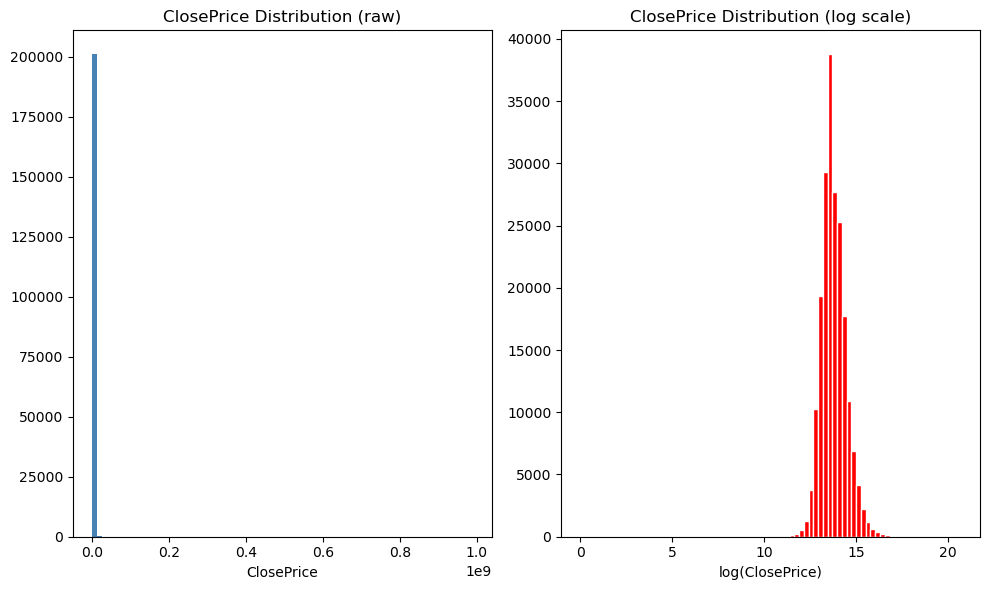

In [8]:
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.hist(df_scoped['ClosePrice'], bins=80, color='steelblue')
plt.xlabel('ClosePrice')
plt.title('ClosePrice Distribution (raw)')

plt.subplot(1,2,2)
plt.hist(np.log1p(df_scoped['ClosePrice']), bins=80, color='red', edgecolor='white')
plt.xlabel('log(ClosePrice)')
plt.title('ClosePrice Distribution (log scale)')
plt.tight_layout()


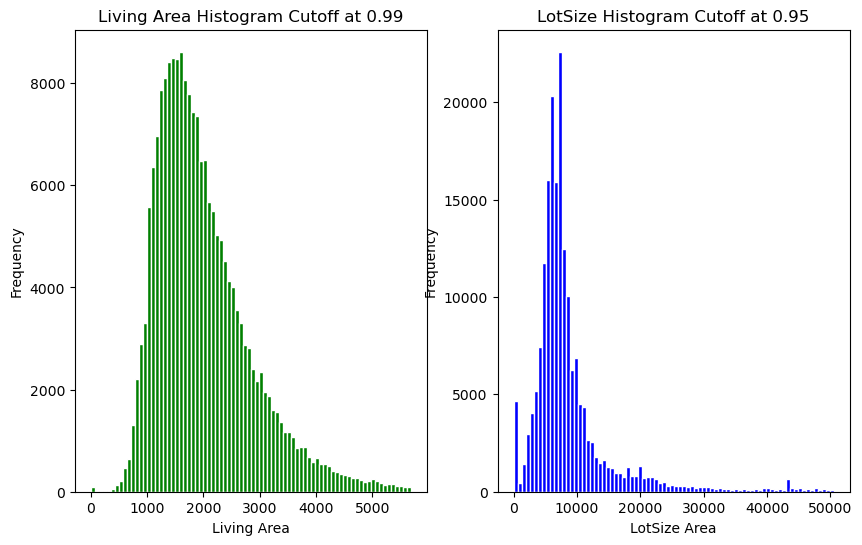

In [9]:
cutoff_living = df_scoped["LivingArea"].quantile(0.99)
df_cutoff_living = df_scoped[df_scoped["LivingArea"] <=cutoff_living]

cutoff_size = df_scoped["LotSizeSquareFeet"].quantile(0.95)
df_cutoff_size = df_scoped[df_scoped["LotSizeSquareFeet"] <= cutoff_size] 

plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.hist(df_cutoff_living["LivingArea"], bins=80, color="green", edgecolor="white")
plt.title("Living Area Histogram Cutoff at 0.99")
plt.xlabel("Living Area")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.hist(df_cutoff_size["LotSizeArea"], bins=80, color="blue", edgecolor="white")
plt.title("LotSize Histogram Cutoff at 0.95")
plt.xlabel("LotSize Area")
plt.ylabel("Frequency")
plt.show()
           

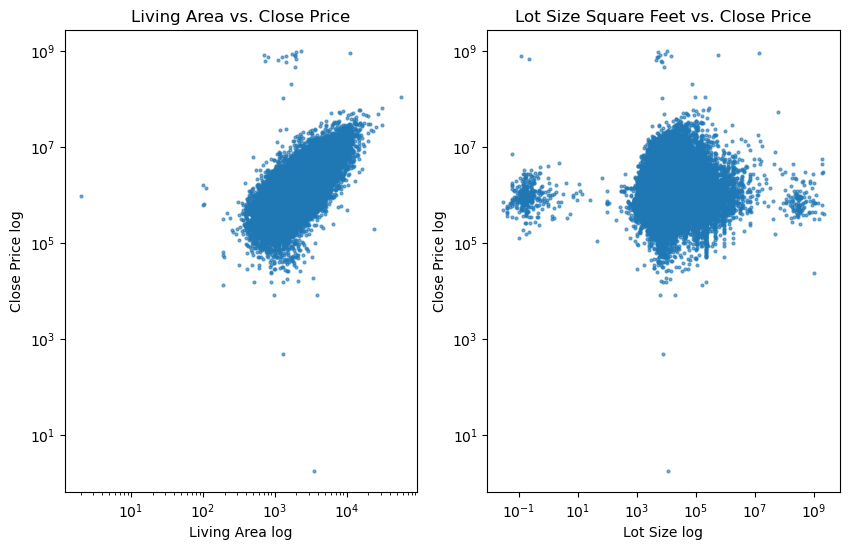

In [10]:
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.scatter(df_scoped["LivingArea"], df_scoped["ClosePrice"], alpha=0.6, s=4)
plt.xscale("log")
plt.yscale("log")
plt.title("Living Area vs. Close Price")
plt.xlabel("Living Area log")
plt.ylabel("Close Price log")

plt.subplot(1,2,2)
plt.scatter(df_scoped["LotSizeSquareFeet"], df_scoped["ClosePrice"], alpha=0.6, s=4)
plt.xscale("log")
plt.yscale("log")
plt.title("Lot Size Square Feet vs. Close Price")
plt.xlabel("Lot Size log")
plt.ylabel("Close Price log")
plt.show()

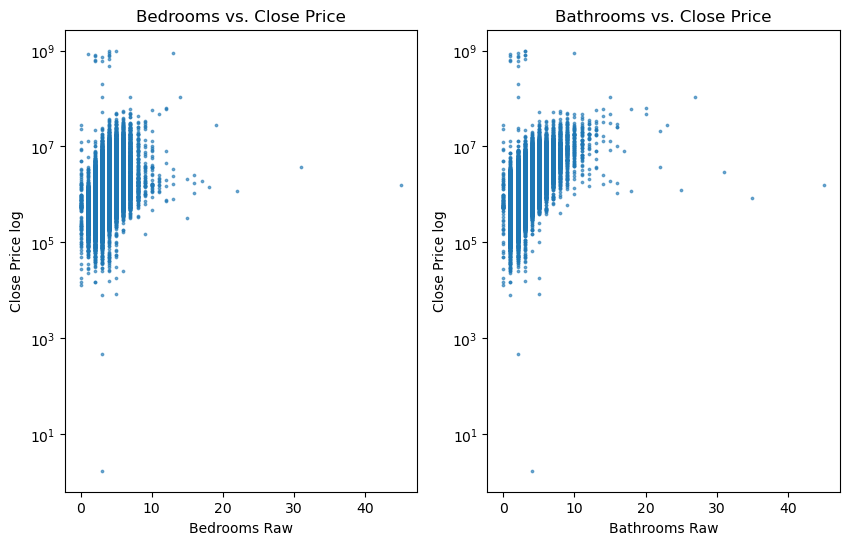

In [11]:
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.scatter(df_scoped["BedroomsTotal"], df_scoped["ClosePrice"], alpha=0.6, s=3)
plt.yscale("log")
plt.title("Bedrooms vs. Close Price")
plt.xlabel("Bedrooms Raw")
plt.ylabel("Close Price log")

plt.subplot(1,2,2)
plt.scatter(df_scoped["BathroomsTotalInteger"], df_scoped["ClosePrice"], alpha=0.6, s=3)
plt.yscale("log")
plt.title("Bathrooms vs. Close Price")
plt.xlabel("Bathrooms Raw")
plt.ylabel("Close Price log")
plt.show()

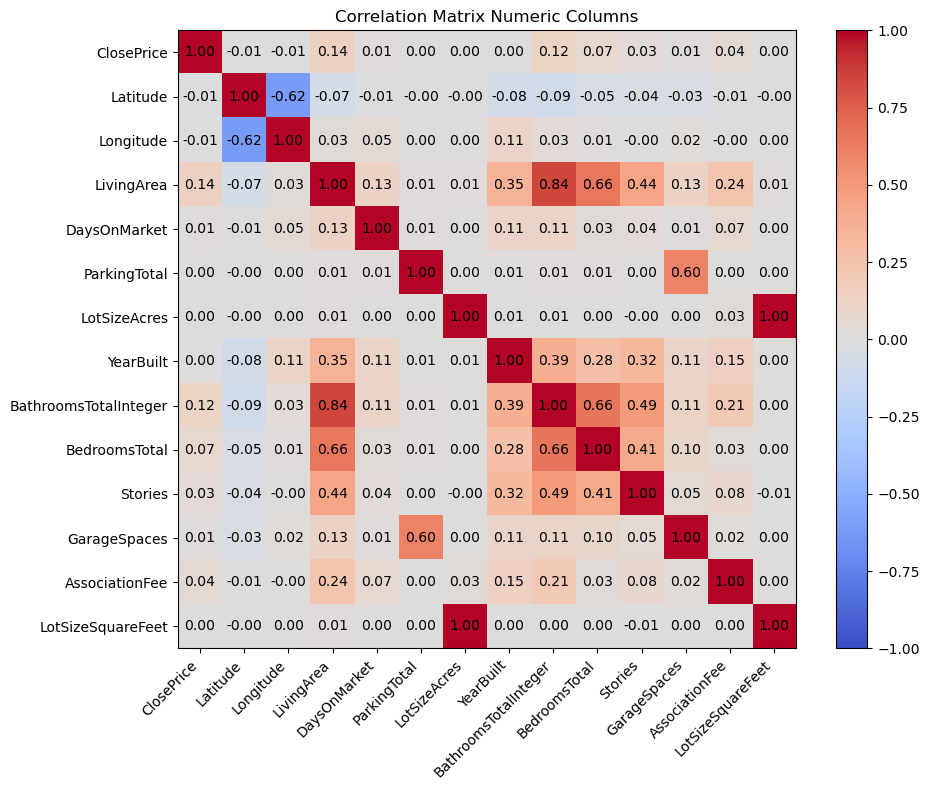

In [12]:

corr_features = ['ClosePrice', 'Latitude','Longitude', 'LivingArea', 'DaysOnMarket','ParkingTotal', 'LotSizeAcres', 'YearBuilt',
                 'BathroomsTotalInteger', 'BedroomsTotal','Stories', 'GarageSpaces', 'AssociationFee','LotSizeSquareFeet']
corr = df_numeric[corr_features].corr()
fig, ax = plt.subplots(figsize=(10,8))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(
            j,i,
            f"{corr.iloc[i,j]:.2f}",
            ha="center",
            va="center",
            color="black")
fig.colorbar(im, ax=ax)
plt.title("Correlation Matrix Numeric Columns")
plt.tight_layout()
plt.show()

The correlation plot shows the strongest relationship between 
1. LivingArea and BathroomsTotalInteger: 0.84
2. LivingArea and BedroomsTotal: 0.66
3. BathroomsTotalInteger and BedroomsTotal: 0.66
4. LivingArea and Stories: 0.44
5. YearBuilt and LivingArea: 0.35


For next week, the main focus will be on preparing the data for modeling, including handling missing values, encoding categorical variables and normalizing numerical features, and splitting the data. 